In [3]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from matplotlib.colors import to_hex
from scipy.optimize import linear_sum_assignment

sys.path.append('../..')
import sherlock as slk

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import matplotlib as mpl

# ── Journal figure style ────────────────────────────────────────────────
RC = {
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        9,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'legend.fontsize':       6,
    'legend.title_fontsize': 7,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3,
    'ytick.major.size':      3,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'pdf.fonttype':          42,
    'ps.fonttype':           42,
    'svg.fonttype': 'none',
}
mpl.rcParams.update(RC)

In [4]:
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS         = 5
NUM_EPOCHS     = 200
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 20
RESULTS_DIR    = "results/benchmarking"
N_CLUSTERS     = 8

# Metrics tracked for scoring and box plots
METRIC_COLS = [
    'cf_ate_pearson_r',
    'cluster_f1',
    'cluster_ari',
    'cluster_ami',
    'cluster_silhouette',
    'cluster_linear_probe',
    'cluster_knn_purity',
]

# (model_key, display_name, method-specific kwargs, num_epochs)
# sherlock (vae) kwargs mirror the tuned hyperparameters in "demo copy.ipynb"
# (cov_lambda / H_lambda / gate_row_repulsion_lambda disabled, ce_lambda raised to 20)
METHODS = [
    ("vae",           "sherlock",      {
        "l0_lambda": 1e-1,
        "ce_lambda": 20.,
        "n_epochs_l0_warmup": 300,
    }, 500),
    ("svae",          "sVAE",          {
        "sparse_mask_penalty": 4.366473592979633,
        "beta": 0.614252574393396,
        "n_hidden": 251,
        "n_layers": 3,
        "dropout_rate": 0.28184968246925673,
        "lr": 0.00331348361550895,
    }, NUM_EPOCHS),
    ("cvae",          "cVAE",          {
        "beta": 3.2226582291306802,
        "n_hidden": 67,
        "n_layers": 1,
        "dropout_rate": 0.29147206450401036,
        "lr": 0.006205861500406846,
    }, NUM_EPOCHS),
    ("contrastivevi", "contrastiveVI", {
        "wasserstein_penalty": 4.399492045282824,
        "n_hidden": 94,
        "n_layers": 2,
        "dropout_rate": 0.2902495045654139,
        "lr": 0.0005218479707033748,
    }, NUM_EPOCHS),
    ("scgen",         "scgen",         {}, NUM_EPOCHS),
]

os.makedirs(f"{RESULTS_DIR}/models",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)

print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/benchmarking


## Data loading and ground-truth ATE

In [5]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|████████████████████████████████████████████████████████████████████████| 681/681 [00:10<00:00, 67.50it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for clustering evaluation

In [6]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Benchmark loop

Each method is trained `N_RUNS` times independently. The best-scoring run
per method is saved to `results/models/`. Metrics are computed after training
using the proper counterfactual ATE protocol; the clustering cut is chosen
automatically via the elbow method.

In [7]:
records         = []
best_run_out    = {}   # method → out dict of best single run
best_run_model  = {}   # method → model of best single run
best_run_score  = {}   # method → avg metric score of best single run

for model_key, display_name, extra_kwargs, EPOCHS, in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    # Each method gets its own folder; individual runs are checkpointed there
    # so a re-executed notebook reloads finished runs instead of retraining.
    model_dir = f"{RESULTS_DIR}/models/{display_name}"
    os.makedirs(model_dir, exist_ok=True)

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")

        run_path = f"{model_dir}/run_{run}.pth"

        if os.path.exists(run_path):
            print(f"    Found checkpoint → {run_path}, loading instead of retraining")
            model = slk.tl.load_results(run_path).to(DEVICE)
            out = {"model": model, "param_store": None}
        else:
            out = slk.tl.run(
                data,
                model=model_key,
                batch_size=BATCH_SIZE,
                num_epochs=EPOCHS,
                device=DEVICE,
                latent_dim=LATENT_DIM,
                patience=PATIENCE,
                validate_every=VALIDATE_EVERY,
                seed=run,
                **extra_kwargs,
            )
            model = out['model']
            slk.tl.save_results(out, run_path)
            print(f"    Saved → {run_path}")

        metrics = slk.tl.evaluate_model(
            model,
            data,
            treat_effect_adata,
            pathway_df_indexed,
            all_genes_filtered,
            n_clusters=N_CLUSTERS,
            device=DEVICE,
            use_rho=False,
        )

        # Track best run for this method
        run_avg = float(metrics['cf_ate_pearson_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out
            best_run_model[display_name] = model

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")

    # Save best run model for this method
    save_path = f"{model_dir}/best.pth"
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f"\n  Saved best {display_name} model → {save_path}")

results_df = pd.DataFrame(records)
print("\nDone.")


sherlock  (5 runs)

  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/500 [00:00<?, ?it/s…

    Saved → results/benchmarking/models/sherlock/run_0.pth
    cf_ate_pearson_r               = 0.7471
    cluster_accuracy               = 0.9910
    cluster_precision              = 0.9902
    cluster_recall                 = 0.9901
    cluster_f1                     = 0.9900
    cluster_ari                    = 0.9813
    cluster_ami                    = 0.9773
    cluster_homogeneity            = 0.9783
    cluster_completeness           = 0.9781
    cluster_v_measure              = 0.9782
    cluster_silhouette             = 0.4323
    cluster_purity                 = 0.9910
    cluster_knn_purity             = 0.9845
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 0.7857

  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/500 [00:00<?, ?it/s…

⏹ Early stopping at epoch 427 (best ELBO=2661.4214)
    Saved → results/benchmarking/models/sherlock/run_1.pth
    cf_ate_pearson_r               = 0.7505
    cluster_accuracy               = 0.9970
    cluster_precision              = 0.9977
    cluster_recall                 = 0.9962
    cluster_f1                     = 0.9969
    cluster_ari                    = 0.9944
    cluster_ami                    = 0.9924
    cluster_homogeneity            = 0.9924
    cluster_completeness           = 0.9931
    cluster_v_measure              = 0.9927
    cluster_silhouette             = 0.4331
    cluster_purity                 = 0.9970
    cluster_knn_purity             = 0.9857
    cluster_linear_probe           = 0.9881
    rho_z_pearson_r                = 0.7559

  -- sherlock run 3/5 --
Training VAE on cuda …


...

    Saved → results/benchmarking/models/scgen/run_2.pth
    cf_ate_pearson_r               = 0.7766
    cluster_accuracy               = 0.8687
    cluster_precision              = 0.8121
    cluster_recall                 = 0.8143
    cluster_f1                     = 0.8040
    cluster_ari                    = 0.8851
    cluster_ami                    = 0.8692
    cluster_homogeneity            = 0.8752
    cluster_completeness           = 0.8741
    cluster_v_measure              = 0.8746
    cluster_silhouette             = 0.2154
    cluster_purity                 = 0.8955
    cluster_knn_purity             = 0.9594
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 1.0000

  -- scgen run 4/5 --


scGEN:   0%|                                                                           | 0/200 [00:00<?, ?it/s…

    Saved → results/benchmarking/models/scgen/run_3.pth
    cf_ate_pearson_r               = 0.7675
    cluster_accuracy               = 0.8746
    cluster_precision              = 0.8248
    cluster_recall                 = 0.8215
    cluster_f1                     = 0.8155
    cluster_ari                    = 0.8773
    cluster_ami                    = 0.8639
    cluster_homogeneity            = 0.8681
    cluster_completeness           = 0.8710
    cluster_v_measure              = 0.8695
    cluster_silhouette             = 0.2293
    cluster_purity                 = 0.8896
    cluster_knn_purity             = 0.9576
    cluster_linear_probe           = 0.9791
    rho_z_pearson_r                = 1.0000

  -- scgen run 5/5 --


scGEN:   0%|                                                                           | 0/200 [00:00<?, ?it/s…

    Saved → results/benchmarking/models/scgen/run_4.pth
    cf_ate_pearson_r               = 0.7749
    cluster_accuracy               = 0.8418
    cluster_precision              = 0.7986
    cluster_recall                 = 0.7529
    cluster_f1                     = 0.7519
    cluster_ari                    = 0.8511
    cluster_ami                    = 0.8285
    cluster_homogeneity            = 0.8286
    cluster_completeness           = 0.8428
    cluster_v_measure              = 0.8356
    cluster_silhouette             = 0.2279
    cluster_purity                 = 0.8627
    cluster_knn_purity             = 0.9564
    cluster_linear_probe           = 0.9821
    rho_z_pearson_r                = 1.0000

  Saved best scgen model → results/benchmarking/models/scgen/best.pth

Done.


## Results summary

In [8]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

              cf_ate_pearson_r         cluster_f1         cluster_ari         cluster_ami         cluster_silhouette         cluster_linear_probe         cluster_knn_purity        
                          mean     std       mean     std        mean     std        mean     std               mean     std                 mean     std               mean     std
method                                                                                                                                                                              
sherlock                0.7447  0.0064     0.9825  0.0279      0.9842  0.0173      0.9809  0.0188             0.4266  0.0070               0.9893  0.0016             0.9842  0.0016
sVAE                    0.4097  0.0099     0.7600  0.1264      0.6815  0.1652      0.7650  0.1394             0.2450  0.0384               0.9881  0.0047             0.9151  0.0295
cVAE                    0.5188  0.0084     0.8357  0.0853      0.8572  0.0933      0.9134  0.04

## Box plots

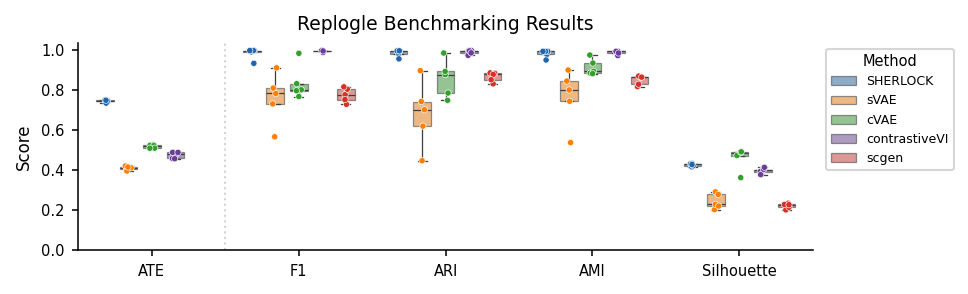

In [9]:
CLR_SHERLOCK    = '#2166ac'
CLR_GEARS       = '#d73027'

METHOD_PALETTE = {
    'SHERLOCK':      CLR_SHERLOCK,
    'cVAE':          '#33a02c',
    'sVAE':          '#ff7f00',
    'contrastiveVI': '#6a3d9a',
    'GEARS':         CLR_GEARS,
}

label_map = {
    'cf_ate_pearson_r':   'ATE',
    'cluster_f1':         'F1',
    'cluster_ari':        'ARI',
    'cluster_ami':        'AMI',
    'cluster_silhouette': 'Silhouette',
    # 'cluster_linear_probe': 'Linear\nProbe',
    # 'cluster_knn_purity': 'kNN\nPurity',
}

METRIC_COLS_PLOT = [
    m for m in METRIC_COLS
    if m not in ['cluster_linear_probe', 'cluster_knn_purity']
]

# Display names matched to METHOD_PALETTE keys (sherlock -> SHERLOCK)
method_display = {
    'sherlock':      'SHERLOCK',
}
method_order = [method_display.get(m[1], m[1]) for m in METHODS]

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS_PLOT, var_name='metric', value_name='value'
)
df_melted['method'] = df_melted['method'].map(lambda m: method_display.get(m, m))
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS_PLOT],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

# scgen has no ATE result to show
df_melted = df_melted[~((df_melted['method'] == 'scgen') & (df_melted['metric'] == 'cf_ate_pearson_r'))]

# Fall back to gray for any method not in METHOD_PALETTE (scgen is colored red)
palette = {m: METHOD_PALETTE.get(m, '#999999') for m in method_order}
palette['scgen'] = CLR_GEARS

fig, ax = plt.subplots(figsize=(6.5, 2))

# NOTE: stripplot's dodge always spans a fixed width of 0.8 (it has no `width`
# kwarg), so the boxplot must also dodge over width=0.8 for box/point centers
# to line up -- otherwise outer hue levels (e.g. scgen) drift off to the side.
# `gap` shrinks the box's visual thickness without moving its dodge position.
sns.boxplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    hue_order=method_order,
    palette=palette,
    width=0.8,
    gap=0.25,
    linewidth=0.6,
    showfliers=False,
    boxprops=dict(alpha=0.55),
    ax=ax,
)

sns.stripplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    hue_order=method_order,
    palette=palette,
    dodge=True,
    jitter=0.1,
    size=3,
    linewidth=0.3,
    edgecolor='white',
    legend=False,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Replogle Benchmarking Results')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE and clustering metrics
ax.axvline(0.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.svg')
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.pdf')
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.png')
plt.show()

## Per-method best models — latent space UMAPs

For each method, re-eval the best run, compute UMAP on non-NTC cells, cluster the
pathway-gene subset of z_corr (maxclust), align predicted clusters to true pathways
via Hungarian matching, and save the figure.


Generating figure for best sherlock model


/var/tmp/ipykernel_591272/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sherlock_best_umap.svg


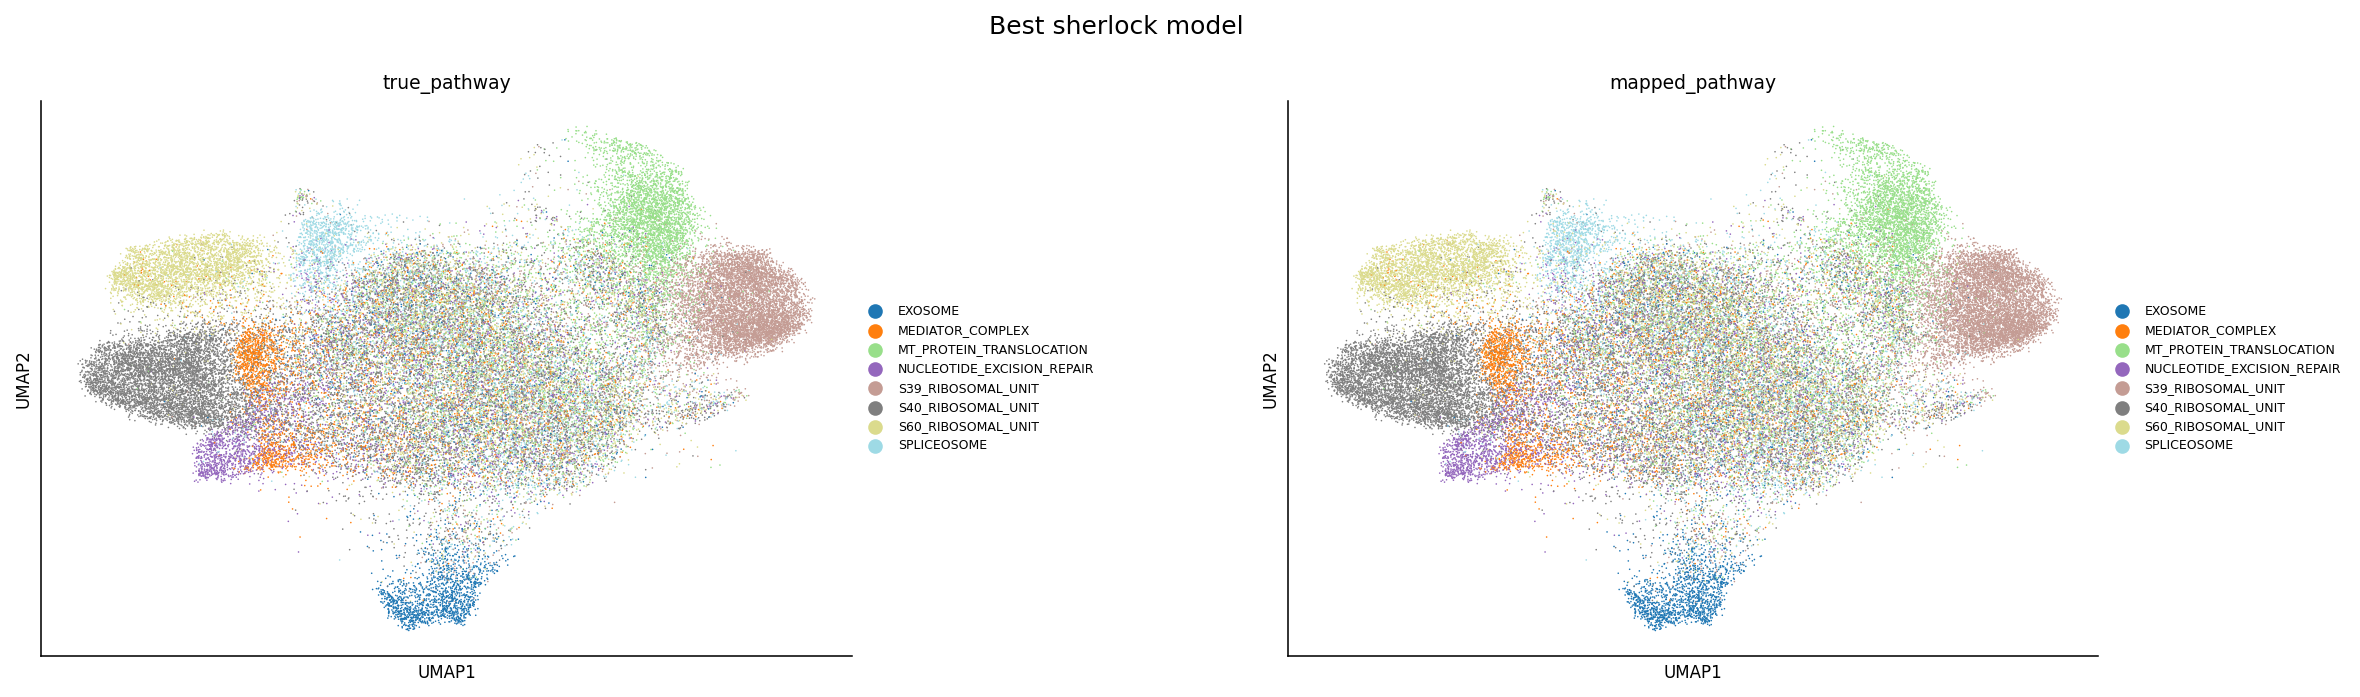


Generating figure for best sVAE model


/var/tmp/ipykernel_591272/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sVAE_best_umap.svg


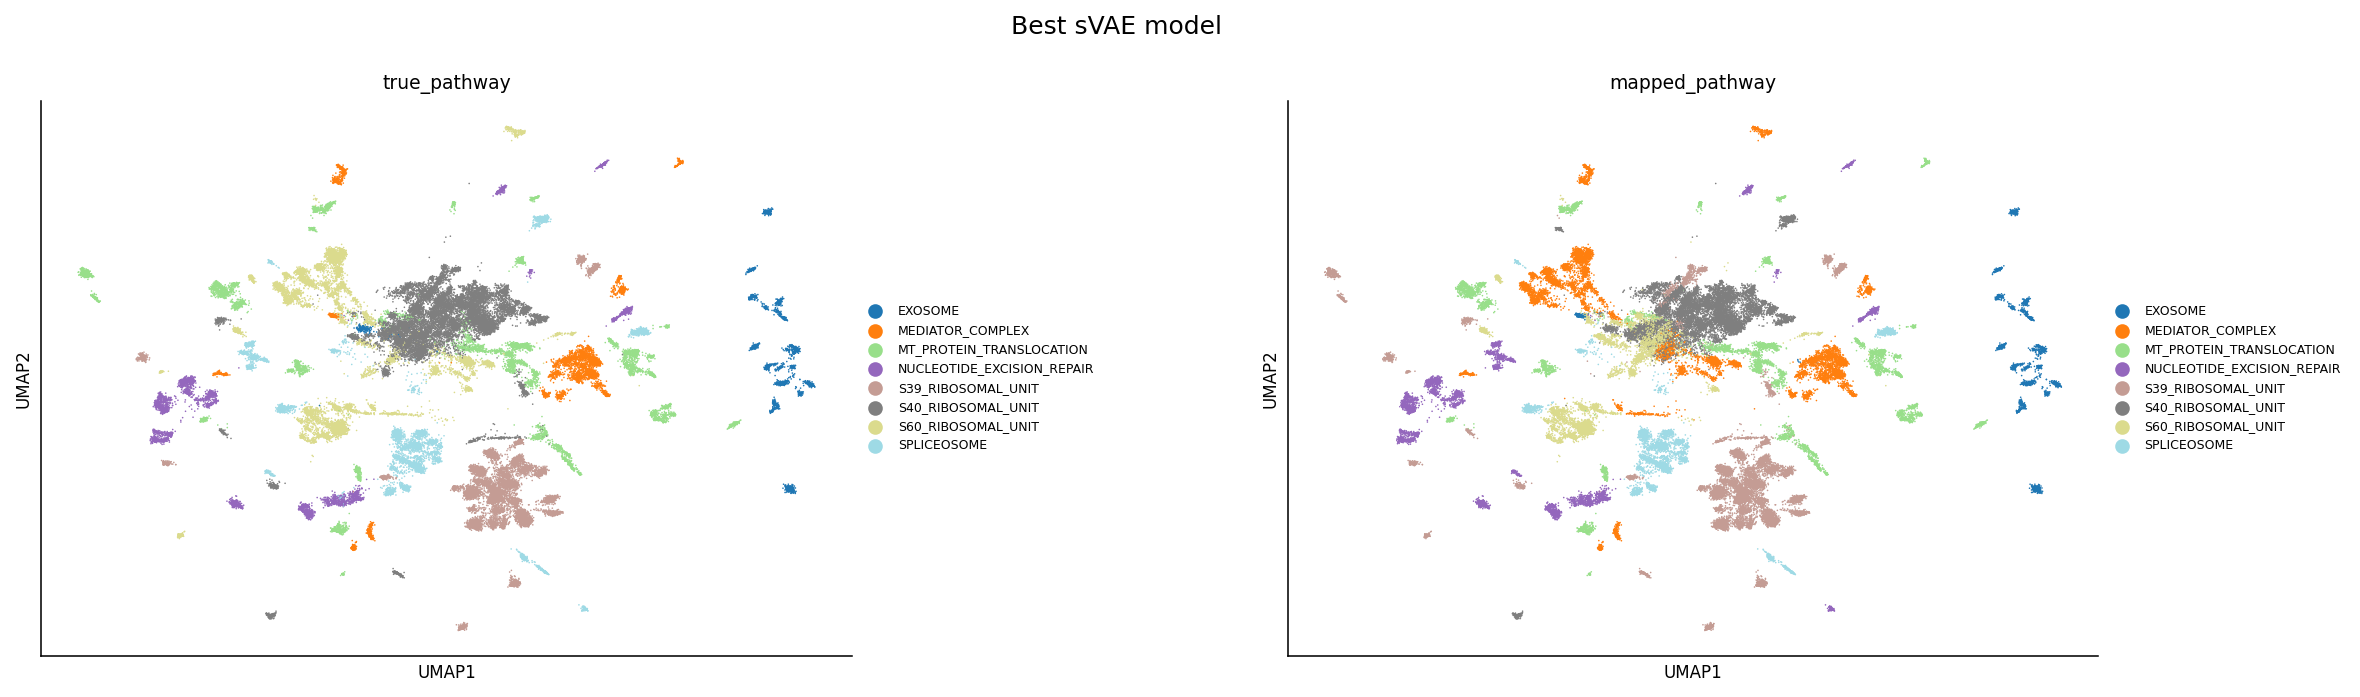


Generating figure for best cVAE model


/home/sc5625/.local/share/mamba/envs/sherlock/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited at iteration 2000 with accuracies 
[1.13411904e-14 5.72461751e-08 1.19873628e-07 1.58063284e-06]
not reaching the requested tolerance 6.556510925292969e-07.
Use iteration 1906 instead with accuracy 
2.4952488984241066e-07.

  _, diffusion_map = lobpcg(
/home/sc5625/.local/share/mamba/envs/sherlock/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited postprocessing with accuracies 
[4.57768560e-15 5.88533827e-08 9.72279537e-08 8.42017963e-07]
not reaching the requested tolerance 6.556510925292969e-07.
  _, diffusion_map = lobpcg(
/var/tmp/ipykernel_591272/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       =

  Saved → results/benchmarking/figures/cVAE_best_umap.svg


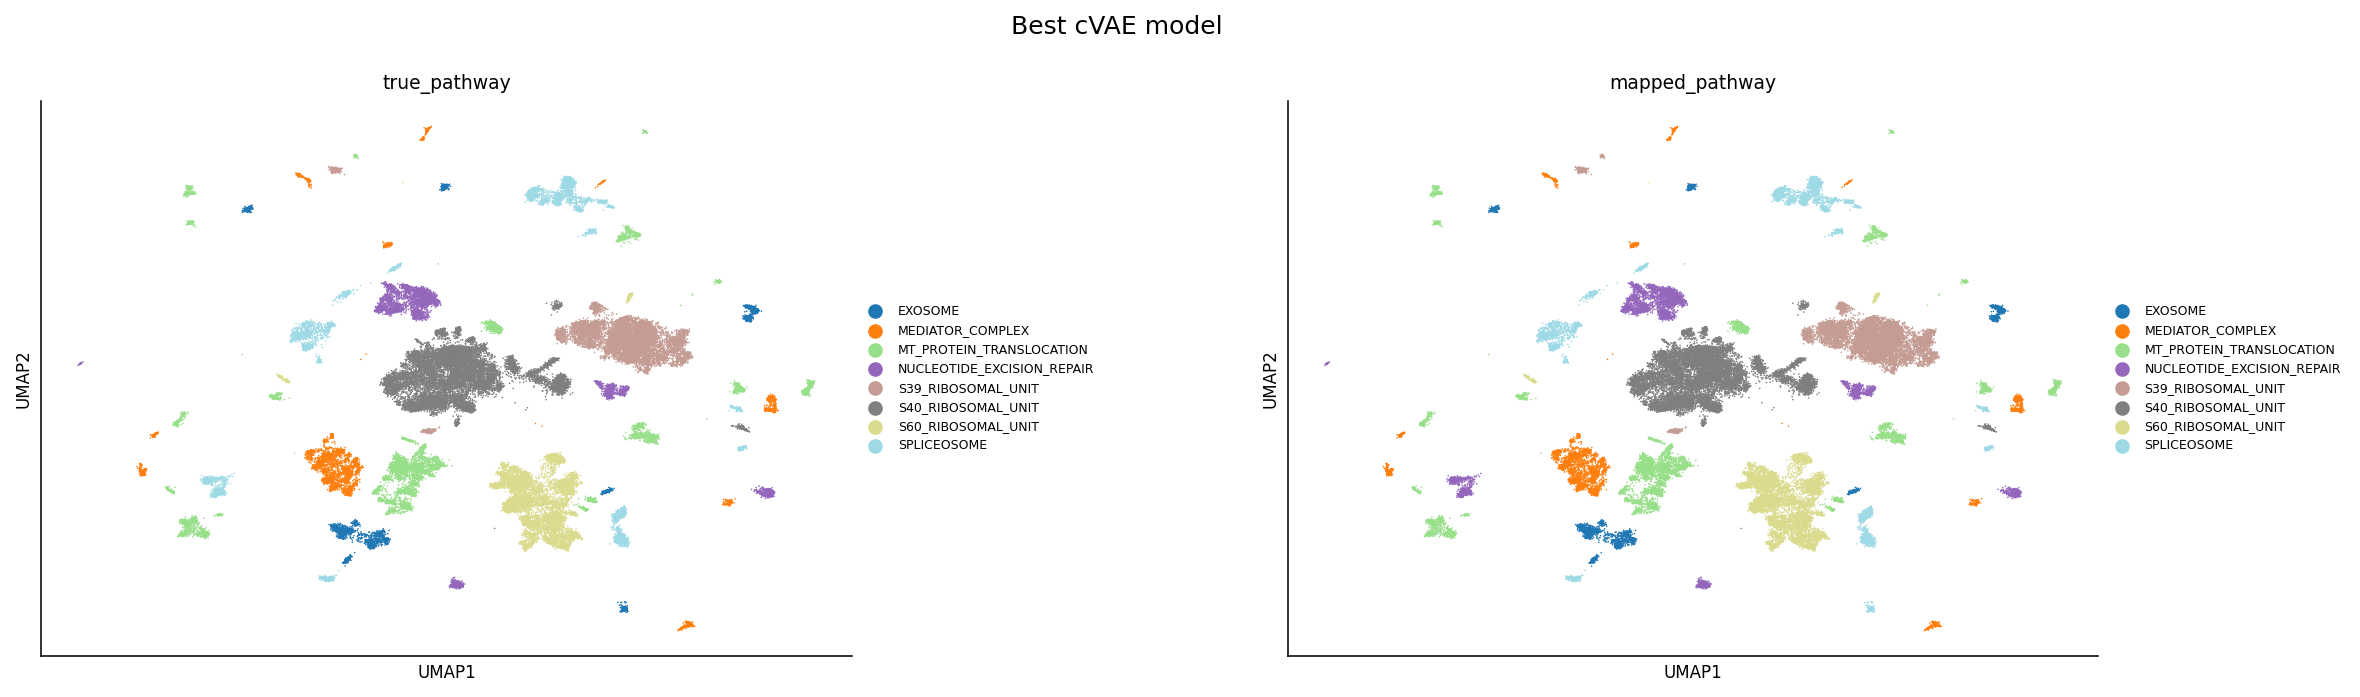


Generating figure for best contrastiveVI model


/var/tmp/ipykernel_591272/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/contrastiveVI_best_umap.svg


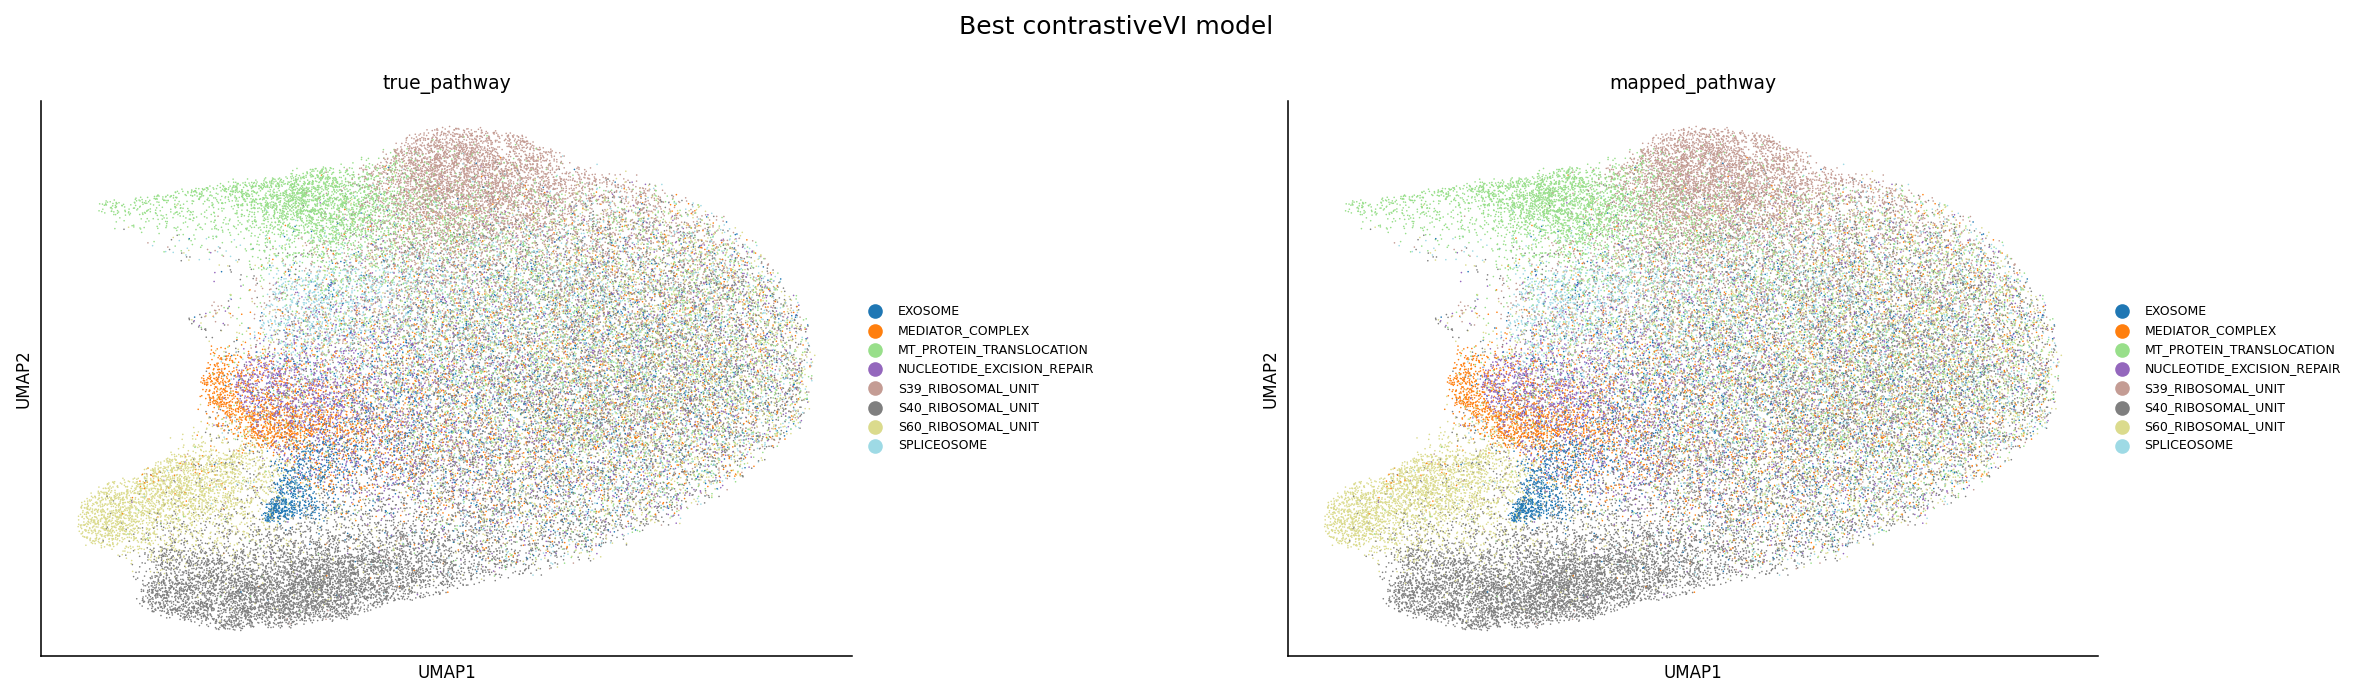


Generating figure for best scgen model


/var/tmp/ipykernel_591272/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/scgen_best_umap.svg


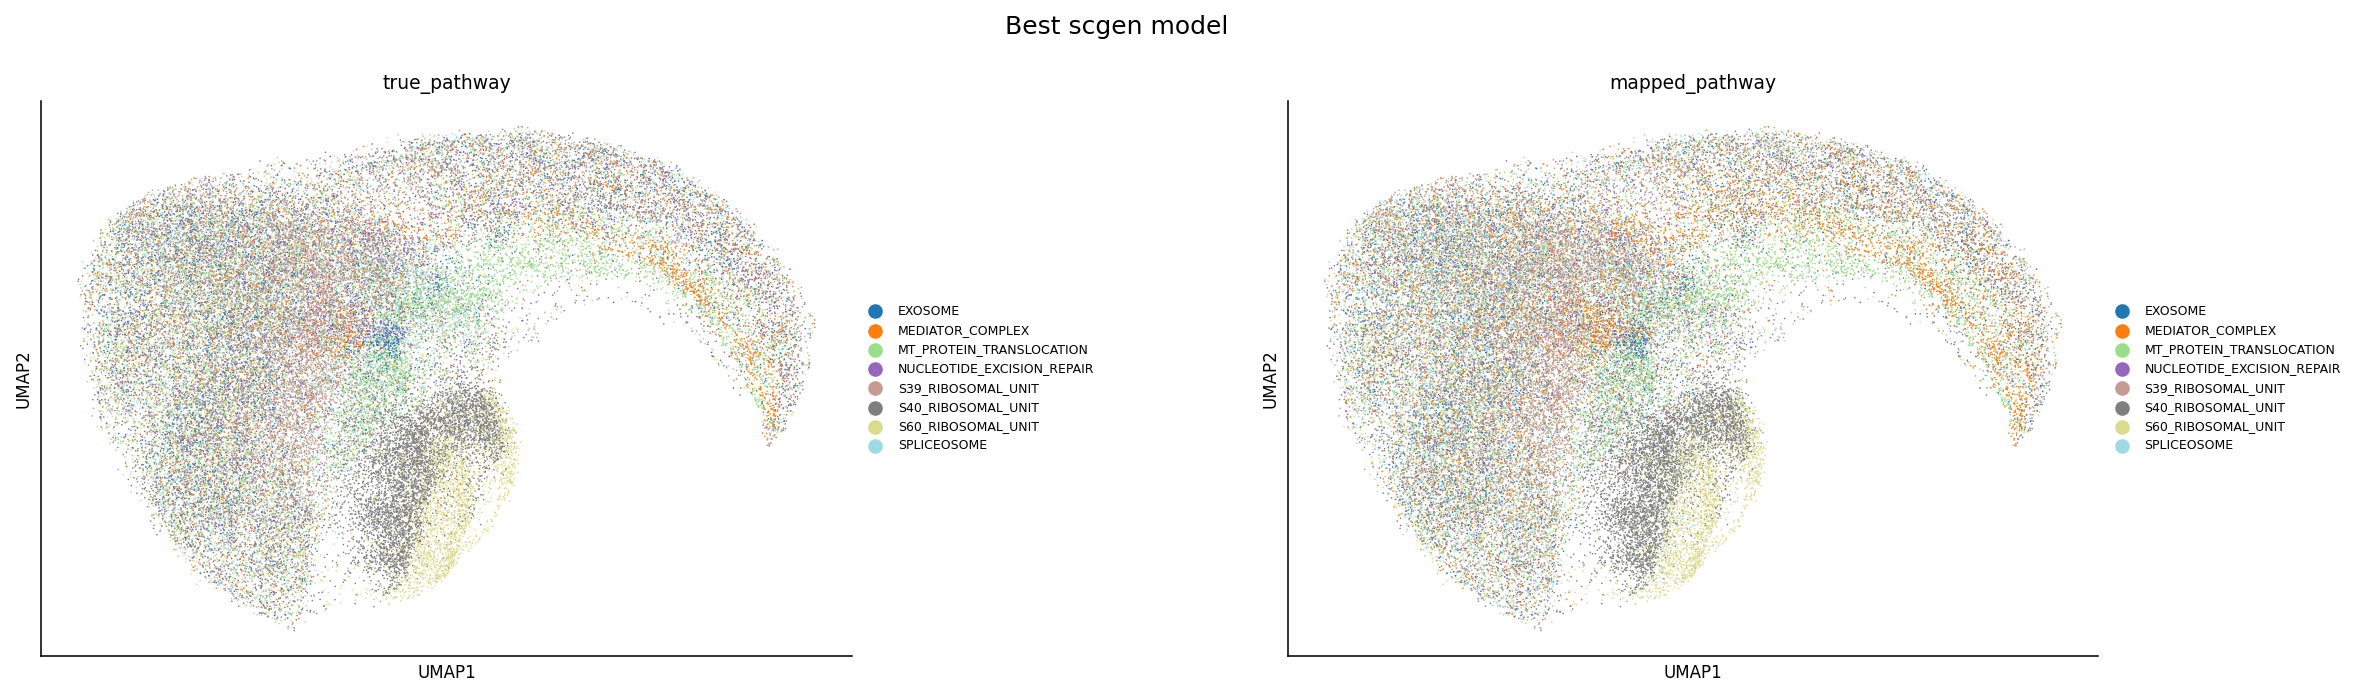

In [7]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

for method_name, model in best_run_model.items():
    print(f"\n{'='*60}\nGenerating figure for best {method_name} model\n{'='*60}")

    # Re-eval the best model for this method
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)

    # UMAP on non-NTC cells
    sub = data[data.obs[p_key] != NTC].copy()
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)

    # Cluster z_corr on pathway genes
    z_corr  = np.asarray(data.uns['results']['z_corr'])
    z_perts = np.asarray(data.uns['results']['z_perts'])

    pert_to_idx = {name: i for i, name in enumerate(z_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = z_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    groups = slk.tl.cluster_rho(data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False)

    # Hungarian alignment of cluster → pathway labels
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': groups})
    pw_df = pathway_df_indexed.loc[pathway_df_indexed.index.isin(valid_genes)].reset_index()
    if 'gene' not in pw_df.columns:
        pw_df = pw_df.rename(columns={pathway_df_indexed.index.name or 'index': 'gene'})

    df_align  = pd.merge(clusters_df, pw_df, on='gene', how='inner')
    y_true    = df_align['pathway'].astype(str).values
    y_pred    = df_align['cluster'].astype(str).values
    true_lbl  = np.unique(y_true)
    pred_lbl  = np.unique(y_pred)

    C_mat = (
        pd.crosstab(df_align['pathway'].astype(str), df_align['cluster'].astype(str))
        .reindex(index=true_lbl, columns=pred_lbl, fill_value=0)
    )
    row_ind, col_ind = linear_sum_assignment(C_mat.values.max() - C_mat.values)
    mapping = {pred_lbl[j]: true_lbl[i] for i, j in zip(row_ind, col_ind)}
    df_align['mapped_pathway'] = [mapping.get(str(cl)) for cl in y_pred]

    # Subset z_sub to clustered genes and attach pathway labels
    clustered_genes = df_align['gene'].unique()
    z_sub = sub[sub.obs[p_key].isin(clustered_genes)].copy()

    gene_to_true   = dict(zip(df_align['gene'], df_align['pathway']))
    gene_to_mapped = dict(zip(df_align['gene'], df_align['mapped_pathway']))
    z_sub.obs['true_pathway']   = z_sub.obs[p_key].map(gene_to_true)
    z_sub.obs['mapped_pathway'] = z_sub.obs[p_key].map(gene_to_mapped)
    z_sub = z_sub[z_sub.obs['mapped_pathway'].notna()].copy()

    # Shared categorical palette across both columns
    all_cats  = pd.Index(np.unique(
        list(z_sub.obs['true_pathway'].dropna().unique()) +
        list(z_sub.obs['mapped_pathway'].dropna().unique())
    ).astype(str))
    cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
    z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
    z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

    cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))
    shared_palette = {cat: to_hex(cmap_col(i)) for i, cat in enumerate(all_cats)}
    z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in z_sub.obs['true_pathway'].cat.categories]
    z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in z_sub.obs['mapped_pathway'].cat.categories]

    # Plot and save
    fig = sc.pl.umap(
        z_sub,
        color=['true_pathway', 'mapped_pathway'],
        wspace=0.4,
        show=False,
        return_fig=True,
    )
    fig.suptitle(f'Best {method_name} model', y=1.02, fontsize=12)
    save_path = f'{RESULTS_DIR}/figures/{method_name}_best_umap.svg'
    fig.savefig(save_path, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()